# Swiss Court Decisions — entscheidsuche.ch Scraper

Collects Swiss court decisions from [entscheidsuche.ch](https://entscheidsuche.ch/) matching
keywords related to parental alienation and child welfare. Used in the comparative legal
analysis chapter of the master's thesis alongside Austrian RIS decisions, ECHR case law,
German court decisions, and Reddit discourse.

**API base:** `https://entscheidsuche.ch/_search.php` (Elasticsearch query DSL, POST)  
**No API key required.** Please cite the platform as data source.  
**Dataset size:** 350,000+ decisions from all Swiss federal and cantonal courts.

---

### Swiss vs Austrian Legal Terminology

Key differences relevant to this thesis:

| Concept | Swiss (CH) | Austrian (AT) |
|---------|-----------|---------------|
| Physical custody | **Obhut** | **Obsorge** |
| Parental authority | **elterliche Sorge** | **Obsorge** (shared term) |
| Visitation / contact rights | **Besuchsrecht** / **Kontaktrecht** | **Kontaktrecht** |
| Child welfare | **Kindeswohl** | **Kindeswohl** (shared) |
| Parental alienation | **Entfremdung** / **elterliche Entfremdung** / **PAS** | same |

---

### Coverage Note

Unlike Germany (de.openlegaldata.io), which only publishes ~1.4% of decisions (skewed toward
higher courts), entscheidsuche.ch aggregates decisions from **all court levels** — federal
(Bundesgericht, BGer) and cantonal (Obergericht, Kantonsgerichte, Bezirksgerichte).
This broader coverage is a significant methodological advantage for this thesis.

**Data source:** entscheidsuche.ch (licensed for academic use — please mention as source)


In [1]:
from __future__ import annotations

import json
import logging
import time
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from bs4 import BeautifulSoup

/Users/maksimsmirnov/Desktop/thesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Configuration

Edit `START_DATE` / `END_DATE` to narrow the collection window.  
`FIELD_*` constants map to the Elasticsearch field names — verify in the exploration
cells below and update if they differ from what the API actually returns.


In [2]:
START_DATE = "2020-01-01"
END_DATE   = "2025-12-31"

REQUEST_DELAY      = 2.0      # seconds between requests — be kind to the server
PAGE_SIZE          = 50       # results per Elasticsearch request
MAX_RESULTS_PER_KW = 10_000   # ES hard limit for from+size pagination
CHECKPOINT_EVERY   = 50       # save checkpoint after this many new cases with full text

# Elasticsearch endpoints
SEARCH_URL          = "https://entscheidsuche.ch/_search.php"
SEARCH_URL_FALLBACK = "https://entscheidsuche.pansoft.de:9200/entscheidsuche-*/_search"
DOCS_BASE           = "https://entscheidsuche.ch/docs/"

# ES field names — confirmed by match_all probe (cell-explore-fields)
FIELD_FULLTEXT = "attachment.content"   # PDF text extracted by ES attachment processor
FIELD_LANGUAGE = "attachment.language"  # language code inside attachment object
FIELD_DATE     = "date"                 # lowercase
FIELD_SIGNATUR = "id"                   # unique case identifier
FIELD_SPIDER   = "hierarchy"            # list e.g. ['AG', 'AG_BG', 'AG_BG_001']

OUTPUT_DIR   = Path("../data/swiss_court_decisions")
OUTPUT_CASES = OUTPUT_DIR / "cases.json"
OUTPUT_KWIC  = OUTPUT_DIR / "kwic.json"
OUTPUT_META  = OUTPUT_DIR / "cases_meta.csv"
CHECKPOINT   = OUTPUT_DIR / "checkpoint.json"
OUTPUT_VIZ   = OUTPUT_DIR / "overview.png"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Output directory: /Users/maksimsmirnov/Desktop/thesis/data/swiss_court_decisions


## Keywords

Each keyword triggers a separate Elasticsearch search. Cases matching multiple keywords
are deduplicated and carry a `matched_keywords` list. **No court type filter** — which
courts and decision types appear is itself an analytical finding.


In [3]:
KEYWORDS = [
    "Entfremdung",
    "Kindeswohl",
    "elterliche Entfremdung",
    "Kontaktrecht",
    "Besuchsrecht",
    "Obhut",
    "Sorgerecht",
    "Kindeswohlgefährdung",
    "elterliche Sorge",
    "PAS",
]

FAMILY_TERMS = [
    "kindeswohl", "sorgerecht", "obhut", "besuchsrecht",
    "kontaktrecht", "elternteil", "kind", "mutter", "vater",
    "familienrecht", "trennung", "scheidung", "umgangsrecht",
    "elterliche sorge", "obsorge",
]

## Logging


In [4]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

session = requests.Session()
session.headers.update({
    "User-Agent": "MasterThesis-Research/1.0 (Academic; msmirnov98@gmail.com)",
    "Content-Type": "application/json",
    "Accept": "application/json",
})

## API Exploration — Run These First

Run these cells once to confirm the endpoint is reachable, identify the actual field
names, and understand the response structure before building the full pipeline.


In [5]:
# Basic connectivity test — POST a minimal Elasticsearch query
query = {
    "query": {
        "bool": {
            "must": [
                {"match": {FIELD_FULLTEXT: "Kindeswohl"}},
                {"match": {FIELD_LANGUAGE: "de"}},
            ]
        }
    },
    "size": 3,
}

resp = session.post(SEARCH_URL, json=query, timeout=30)
print(f"Primary endpoint status: {resp.status_code}")

if resp.ok:
    data = resp.json()
    total = data.get("hits", {}).get("total", {})
    print(f"Total hits: {total}")
    print(json.dumps(data, indent=2, ensure_ascii=False)[:3000])
else:
    print(f"Primary failed: {resp.text[:300]}")
    print("\nTrying fallback endpoint...")
    resp2 = session.post(SEARCH_URL_FALLBACK, json=query, timeout=30)
    print(f"Fallback status: {resp2.status_code}")
    if resp2.ok:
        print(json.dumps(resp2.json(), indent=2, ensure_ascii=False)[:3000])
    else:
        print(f"Fallback also failed: {resp2.text[:300]}")

Primary endpoint status: 200
Total hits: {'value': 7003, 'relation': 'eq'}
{
  "took": 27,
  "timed_out": false,
  "_shards": {
    "total": 54,
    "successful": 54,
    "skipped": 0,
    "failed": 0
  },
  "hits": {
    "total": {
      "value": 7003,
      "relation": "eq"
    },
    "max_score": 12.7247925,
    "hits": [
      {
        "_index": "entscheidsuche.v2-zh_sozialversicherungsgericht",
        "_type": "_doc",
        "_id": "ZH_SVG_001_IV-2019-00051_2019-02-12",
        "_score": 12.7247925,
        "_source": {
          "date": "2019-02-12",
          "hierarchy": [
            "ZH",
            "ZH_SVG",
            "ZH_SVG_001"
          ],
          "abstract": {
            "de": "Akteneinsichtsgesuch einer nicht sorge- und obhutsberechtigten Mutter; Vollmachtsunterzeichnung durch Sohn als Minderjähriger; Abweisung",
            "it": "Akteneinsichtsgesuch einer nicht sorge- und obhutsberechtigten Mutter; Vollmachtsunterzeichnung durch Sohn als Minderjähriger; Abw

In [6]:
# Inspect all _source fields in a hit — confirm FIELD_* constants match actual names
resp = session.post(SEARCH_URL, json={"query": {"match_all": {}}, "size": 1}, timeout=30)
data = resp.json()
hits = data.get("hits", {}).get("hits", [])

if hits:
    src = hits[0].get("_source", {})
    print(f"_id:    {hits[0].get('_id')}")
    print(f"_index: {hits[0].get('_index')}")
    print("\n_source fields:")
    for k, v in src.items():
        print(f"  {k!r:25s}: {type(v).__name__:8s} = {str(v)[:120]!r}")
else:
    print("No hits returned.")

_id:    AG_BG_001_Adressat-einer-Besei_1994-02-21
_index: entscheidsuche.v2-ag_baugesetzgebung

_source fields:
  'date'                   : str      = '1994-02-21'
  'hierarchy'              : list     = "['AG', 'AG_BG', 'AG_BG_001']"
  'abstract'               : dict     = "{'de': 'Der Beseitigungsbefehl geht an den Störer. Bei einer Mehrzahl von Störern liegt es im pflichtgemässen Ermessen d"
  'source'                 : str      = '446973/78/8'
  'title'                  : dict     = "{'de': 'Aargau Entscheidsammlung Baugesetzgebung 21.02.1994', 'it': 'Argovia Entscheidsammlung Baugesetzgebung 21.02.199"
  'reference'              : list     = "['Adressat einer Beseitigungsverfügung']"
  'attachment'             : dict     = "{'date': '2006-03-28T13:44:10Z', 'content_type': 'application/pdf', 'author': 'PMOA', 'language': 'de', 'content_url': '"
  'meta'                   : dict     = "{'de': 'Aargau Entscheidsammlung Baugesetzgebung ', 'it': 'Argovia Entscheidsammlung Baugesetzgeb

In [7]:
# Verify date-range and language filters; update FIELD_* constants above if needed
query_filtered = {
    "query": {
        "bool": {
            "must": [{"match": {FIELD_FULLTEXT: "Kindeswohl"}}],
            "filter": [
                {"term":  {FIELD_LANGUAGE: "de"}},
                {"range": {FIELD_DATE: {"gte": START_DATE, "lte": END_DATE}}},
            ],
        }
    },
    "size": 3,
    "_source": {"excludes": [FIELD_FULLTEXT]},
}
resp = session.post(SEARCH_URL, json=query_filtered, timeout=30)
data = resp.json()
total = data.get("hits", {}).get("total", {})
print(f"Filtered hits (de, {START_DATE}\u2013{END_DATE}): {total}")
for hit in data.get("hits", {}).get("hits", []):
    src = hit.get("_source", {})
    print(f"  {src.get(FIELD_SIGNATUR, '?'):20s}  {src.get(FIELD_DATE, '?')}  "
          f"{src.get(FIELD_SPIDER, '?')}")

Filtered hits (de, 2020-01-01–2025-12-31): {'value': 3298, 'relation': 'eq'}
  FR_TC_001_101-2019-268_2020-01-10  2020-01-10  ['FR', 'FR_TC', 'FR_TC_001']
  FR_TC_001_101-2021-233_2021-11-24  2021-11-24  ['FR', 'FR_TC', 'FR_TC_001']
  FR_TC_004_106-2021-60_2021-09-27  2021-09-27  ['FR', 'FR_TC', 'FR_TC_004']


In [8]:
# Test HTML full-text fetch for one case
resp = session.post(SEARCH_URL, json={
    "query": {"term": {FIELD_LANGUAGE: "de"}},
    "size": 1,
    "_source": [FIELD_SIGNATUR, FIELD_SPIDER, FIELD_DATE, "HTML"],
}, timeout=30)

hits = resp.json().get("hits", {}).get("hits", [])
if hits:
    src      = hits[0].get("_source", {})
    html_meta = src.get("HTML") or {}
    datei    = html_meta.get("Datei", "")
    print(f"Signatur:   {src.get(FIELD_SIGNATUR)}")
    print(f"HTML.Datei: {datei}")
    print(f"HTML.URL:   {html_meta.get('URL', '')}")

    if datei:
        html_url = DOCS_BASE + datei
        print(f"\nFetching: {html_url}")
        r = session.get(html_url, timeout=30)
        print(f"Status: {r.status_code}  ({len(r.content)} bytes)")
        if r.ok:
            text = BeautifulSoup(r.content, "html.parser").get_text(separator="\n", strip=True)
            print(f"Plain text ({len(text)} chars):\n{text[:600]}")

Signatur:   TI_TCAS_001_30-2007-46_2007-09-20
HTML.Datei: 
HTML.URL:   


## Helper Functions


In [9]:
def html_to_text(html):
    if not html:
        return ""
    return BeautifulSoup(html, "html.parser").get_text(separator="\n", strip=True)


def extract_kwic(text, keyword, window=200):
    contexts = []
    if not text:
        return contexts
    text_lower = text.lower()
    kw_lower = keyword.lower()
    start = 0
    while True:
        idx = text_lower.find(kw_lower, start)
        if idx == -1:
            break
        ctx_start = max(0, idx - window)
        ctx_end = min(len(text), idx + len(keyword) + window)
        contexts.append({
            "keyword":  keyword,
            "position": idx,
            "context":  text[ctx_start:ctx_end].strip(),
        })
        start = idx + 1
    return contexts


def parse_year(date_str):
    if not date_str:
        return None
    try:
        return int(str(date_str)[:4])
    except (ValueError, TypeError):
        return None


def in_date_range(date_str):
    if not date_str:
        return False
    return START_DATE <= str(date_str)[:10] <= END_DATE


def parse_spider(spider):
    # "CH_BGer" -> ("CH", "BGer")  /  "GL_Omni" -> ("GL", "Omni")
    if not spider:
        return ("", "")
    parts = spider.split("_", 1)
    return (parts[0], parts[1] if len(parts) > 1 else "")

In [10]:
def is_family_law_relevant(text):
    if not text:
        return False
    text_lower = text.lower()
    return sum(1 for t in FAMILY_TERMS if t in text_lower) >= 2

In [11]:
def es_post(body, retries=3):
    for url in [SEARCH_URL, SEARCH_URL_FALLBACK]:
        for attempt in range(retries):
            try:
                time.sleep(REQUEST_DELAY if attempt == 0 else 5)
                r = session.post(url, json=body, timeout=30)
                if r.status_code == 200:
                    return r.json()
                if r.status_code in (429, 503):
                    wait = 30 * (attempt + 1)
                    log.warning(f"HTTP {r.status_code} on {url} (attempt {attempt+1}), "
                                f"waiting {wait}s")
                    time.sleep(wait)
                    continue
                log.warning(f"HTTP {r.status_code} on {url}: {r.text[:120]}")
                break   # non-transient error — try fallback URL
            except (requests.exceptions.RequestException, ValueError) as e:
                log.warning(f"Request error attempt {attempt+1} ({url}): {e}")
                time.sleep(3 * attempt)
    log.error("Both Elasticsearch endpoints failed")
    return None


def fetch_html_text(datei, retries=3):
    if not datei:
        return None
    url = DOCS_BASE + datei
    for attempt in range(retries):
        try:
            time.sleep(REQUEST_DELAY if attempt == 0 else 5)
            r = session.get(url, timeout=30)
            if r.status_code == 200:
                return html_to_text(r.content)
            if r.status_code == 404:
                log.debug(f"Document removed (404): {url}")
                return None
            if r.status_code in (429, 503):
                time.sleep(30 * (attempt + 1))
                continue
            log.warning(f"HTTP {r.status_code} fetching HTML: {url}")
            break
        except (requests.exceptions.RequestException, ValueError) as e:
            log.warning(f"HTML fetch error attempt {attempt+1}: {e}")
            time.sleep(3 * attempt)
    return None

In [12]:
def search_keyword(keyword):
    results = []
    from_idx = 0
    total_val = None

    while from_idx < MAX_RESULTS_PER_KW:
        body = {
            "query": {
                "bool": {
                    "must": [{"match": {FIELD_FULLTEXT: keyword}}],
                    "filter": [
                        {"term":  {FIELD_LANGUAGE: "de"}},
                        {"range": {FIELD_DATE: {"gte": START_DATE, "lte": END_DATE}}},
                    ],
                }
            },
            "size": PAGE_SIZE,
            "from": from_idx,
            "sort": [{FIELD_DATE: "desc"}],
            "_source": {"excludes": [FIELD_FULLTEXT]},
        }

        data = es_post(body)
        if not data:
            log.warning(f"[{keyword}] No data at from={from_idx}, stopping")
            break

        hits_meta = data.get("hits", {})
        total_obj = hits_meta.get("total", {})
        total_val = (total_obj.get("value", 0)
                     if isinstance(total_obj, dict) else int(total_obj or 0))
        hits = hits_meta.get("hits", [])

        if not hits:
            break

        page_num = from_idx // PAGE_SIZE + 1
        log.info(f"[{keyword}] page {page_num} (from={from_idx}): "
                 f"{len(hits)} hits  (total: {total_val})")

        for hit in hits:
            src = hit.get("_source", {})
            # Inject the doc id into _source so downstream code can find it
            src.setdefault("id", hit.get("_id", ""))
            results.append(src)

        from_idx += PAGE_SIZE
        if from_idx >= total_val:
            break

    if total_val and from_idx >= MAX_RESULTS_PER_KW and total_val > MAX_RESULTS_PER_KW:
        log.warning(f"[{keyword}] Hit MAX_RESULTS_PER_KW={MAX_RESULTS_PER_KW}; "
                    f"total was {total_val} — some results truncated")

    log.info(f"[{keyword}] -> {len(results)} results collected")
    return results

In [13]:
def load_checkpoint():
    if not CHECKPOINT.exists():
        return {}, []
    try:
        with open(CHECKPOINT, encoding="utf-8") as f:
            data = json.load(f)
        cases = {c["Signatur"]: c for c in data.get("cases", []) if c.get("Signatur")}
        kwic  = data.get("kwic", [])
        log.info(f"Checkpoint loaded: {len(cases)} cases, {len(kwic)} KWIC entries")
        return cases, kwic
    except Exception as e:
        log.warning(f"Could not load checkpoint ({e}) — starting fresh")
        return {}, []


def save_checkpoint(cases_by_sig, kwic_list):
    try:
        data = {
            "saved_at": datetime.now().isoformat(timespec="seconds"),
            "cases":    list(cases_by_sig.values()),
            "kwic":     kwic_list,
        }
        with open(CHECKPOINT, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        log.info(f"Checkpoint saved: {len(cases_by_sig)} cases, {len(kwic_list)} KWIC entries")
    except Exception as e:
        log.warning(f"Could not save checkpoint: {e}")

## Phase 1 — Collect Search Hits

For each keyword, query Elasticsearch and collect metadata for all matching cases
within the date range. Cases are deduplicated by `Signatur`; `matched_keywords`
accumulates across all keyword searches.


In [14]:
cases_by_sig, kwic_list = load_checkpoint()
log.info(f"Starting with {len(cases_by_sig)} cases already in checkpoint")

sig_to_keywords = {
    sig: set(c.get("matched_keywords", []))
    for sig, c in cases_by_sig.items()
}
search_hits: dict = {}
keyword_raw_counts: dict = {}

11:55:32  INFO      Checkpoint loaded: 0 cases, 0 KWIC entries
11:55:32  INFO      Starting with 0 cases already in checkpoint


In [15]:
for i, keyword in enumerate(KEYWORDS):
    results = search_keyword(keyword)
    keyword_raw_counts[keyword] = len(results)

    for src in results:
        sig = src.get(FIELD_SIGNATUR)
        if not sig:
            continue
        if sig not in search_hits:
            search_hits[sig] = src
        sig_to_keywords.setdefault(sig, set()).add(keyword)

    if i < len(KEYWORDS) - 1:
        time.sleep(REQUEST_DELAY)

log.info(f"Total unique cases found across all keywords: {len(search_hits)}")
print(f"\nRaw hits per keyword:")
for kw, n in keyword_raw_counts.items():
    print(f"  {n:>6}  {kw}")
print(f"{'─'*32}")
print(f"  {len(search_hits):>6}  unique cases total")

11:55:35  INFO      [Entfremdung] page 1 (from=0): 50 hits  (total: 437)
11:55:37  INFO      [Entfremdung] page 2 (from=50): 50 hits  (total: 437)
11:55:40  INFO      [Entfremdung] page 3 (from=100): 50 hits  (total: 437)
11:55:42  INFO      [Entfremdung] page 4 (from=150): 50 hits  (total: 437)
11:55:45  INFO      [Entfremdung] page 5 (from=200): 50 hits  (total: 437)
11:55:48  INFO      [Entfremdung] page 6 (from=250): 50 hits  (total: 437)
11:55:50  INFO      [Entfremdung] page 7 (from=300): 50 hits  (total: 437)
11:55:53  INFO      [Entfremdung] page 8 (from=350): 50 hits  (total: 437)
11:55:55  INFO      [Entfremdung] page 9 (from=400): 37 hits  (total: 437)
11:55:55  INFO      [Entfremdung] -> 437 results collected
11:56:00  INFO      [Kindeswohl] page 1 (from=0): 50 hits  (total: 3298)
11:56:03  INFO      [Kindeswohl] page 2 (from=50): 50 hits  (total: 3298)
11:56:06  INFO      [Kindeswohl] page 3 (from=100): 50 hits  (total: 3298)
11:56:08  INFO      [Kindeswohl] page 4 (from=1


Raw hits per keyword:
     437  Entfremdung
    3298  Kindeswohl
    3100  elterliche Entfremdung
     457  Kontaktrecht
    2498  Besuchsrecht
    4260  Obhut
     977  Sorgerecht
     634  Kindeswohlgefährdung
    3550  elterliche Sorge
    1401  PAS
────────────────────────────────
   10061  unique cases total


## Phase 2 — Fetch Full Texts

For each unique case not already in the checkpoint, download the HTML file via
`HTML.Datei` and extract plain text. Checkpoints every `CHECKPOINT_EVERY` cases
so interrupted runs can resume.


In [16]:
new_since_checkpoint = 0
sigs_to_fetch = [s for s in search_hits if s not in cases_by_sig]
log.info(f"Cases to fetch: {len(sigs_to_fetch)} "
         f"(skipping {len(cases_by_sig)} already in checkpoint)")

for i, sig in enumerate(sigs_to_fetch):
    src       = search_hits[sig]
    html_meta = src.get("attachment") or {}
    datei     = html_meta.get("content_url", "")
    # hierarchy is e.g. ['AG', 'AG_BG', 'AG_BG_001']
    hierarchy = src.get("hierarchy") or []
    canton     = hierarchy[0] if len(hierarchy) > 0 else ""
    court_type = hierarchy[1] if len(hierarchy) > 1 else ""
    date_str  = str(src.get(FIELD_DATE, ""))[:10]

    log.info(f"[{i+1}/{len(sigs_to_fetch)}] {sig}  ({date_str})")

    full_text = fetch_html_text(datei) if datei else None

    # Abstract is a dict keyed by language code e.g. {"de": "..."}
    abstract_obj = src.get("abstract") or {}
    abstract_text = (abstract_obj.get("de") or next(iter(abstract_obj.values()), "")
                     if isinstance(abstract_obj, dict) else "")

    case = {
        "Signatur":        sig,
        "Spider":          "/".join(hierarchy),
        "canton":          canton,
        "court_type":      court_type,
        "Sprache":         src.get(FIELD_LANGUAGE, ""),
        "Datum":           date_str,
        "year":            parse_year(date_str),
        "HTML_Datei":      datei,
        "HTML_URL":        datei,
        "Num":             src.get("reference") or [],
        "abstract":        abstract_text,
        "content":         full_text or "",
        "text_length":     len(full_text) if full_text else 0,
        "family_relevant": is_family_law_relevant(full_text),
        "matched_keywords": sorted(sig_to_keywords.get(sig, set())),
    }
    cases_by_sig[sig] = case
    new_since_checkpoint += 1

    if new_since_checkpoint >= CHECKPOINT_EVERY:
        save_checkpoint(cases_by_sig, kwic_list)
        new_since_checkpoint = 0

save_checkpoint(cases_by_sig, kwic_list)

# Refresh matched_keywords + family_relevant for cases already in checkpoint
for sig, kw_set in sig_to_keywords.items():
    if sig in cases_by_sig:
        existing = set(cases_by_sig[sig].get("matched_keywords", []))
        cases_by_sig[sig]["matched_keywords"] = sorted(existing | kw_set)
        cases_by_sig[sig]["family_relevant"] = is_family_law_relevant(
            cases_by_sig[sig].get("content", "")
        )

n_with_text = sum(1 for c in cases_by_sig.values() if c.get("text_length", 0) > 100)
n_relevant  = sum(1 for c in cases_by_sig.values() if c.get("family_relevant"))
print(f"\nCases collected : {len(cases_by_sig)}")
print(f"With full text  : {n_with_text}")
print(f"Family relevant : {n_relevant}")

12:59:51  INFO      Cases to fetch: 10061 (skipping 0 already in checkpoint)
12:59:51  INFO      [1/10061] ZH_OG_001_LZ250034_2025-12-30  (2025-12-30)
12:59:53  INFO      [2/10061] SZ_VG_001_III-2025-212_2025-12-30  (2025-12-30)
12:59:55  INFO      [3/10061] SZ_KG_001_ZK1-2025-2_2025-12-29  (2025-12-29)
12:59:57  INFO      [4/10061] ZH_OG_001_PQ250067_2025-12-18  (2025-12-18)
12:59:59  INFO      [5/10061] ZH_OG_001_RS250021_2025-12-18  (2025-12-18)
13:00:01  INFO      [6/10061] ZH_VG_001_-VB-2025-00339_2025-12-18  (2025-12-18)
13:00:04  INFO      [7/10061] SZ_VG_001_III-2025-141_2025-12-18  (2025-12-18)
13:00:06  INFO      [8/10061] ZH_OG_001_LE240027_2025-12-11  (2025-12-11)
13:00:08  INFO      [9/10061] SZ_KG_004_BEK-2025-147_2025-11-28  (2025-11-28)
13:00:10  INFO      [10/10061] SZ_KG_004_BEK-2025-148_2025-11-28  (2025-11-28)
13:00:12  INFO      [11/10061] SO_VG_001_VWBES-2024-185_2025-11-27  (2025-11-27)
13:00:14  INFO      [12/10061] SO_VG_001_VWBES-2024-408_2025-11-19  (2025-11-

KeyboardInterrupt: 

In [19]:
# Quick recovery — load checkpoint and save metadata CSV
import json, pandas as pd
from pathlib import Path

with open("../data/swiss_court_decisions/checkpoint.json", encoding="utf-8") as f:
    ckpt = json.load(f)

cases = ckpt["cases"]
print(f"Cases in checkpoint: {len(cases)}")

rows = []
for c in cases:
    rows.append({
        "id":              c.get("Signatur", ""),
        "canton":          c.get("canton", ""),
        "court_type":      c.get("court_type", ""),
        "date":            c.get("Datum", ""),
        "year":            c.get("year", ""),
        "matched_keywords": "; ".join(c.get("matched_keywords") or []),
        "abstract":        c.get("abstract", "")[:200],
    })

df = pd.DataFrame(rows)
df.to_csv("../data/swiss_court_decisions/cases_meta.csv", index=False, encoding="utf-8-sig")
print(df["canton"].value_counts().head(10))
print(df["year"].value_counts().sort_index())


Cases in checkpoint: 820
canton
CH    293
ZH    212
AG     66
SO     45
BS     38
GR     36
BL     29
BE     26
SG     19
SZ     15
Name: count, dtype: int64
year
2020     63
2021     76
2022     81
2023     79
2024     78
2025    443
Name: count, dtype: int64


temp 

In [22]:
# Quick KWIC from checkpoint abstracts — no full text needed
import json
from pathlib import Path

with open("../data/swiss_court_decisions/checkpoint.json", encoding="utf-8") as f:
    ckpt = json.load(f)

cases = ckpt["cases"]

def extract_kwic(text, keyword, window=400):
    contexts = []
    if not text:
        return contexts
    text_lower = text.lower()
    kw_lower = keyword.lower()
    start = 0
    while True:
        idx = text_lower.find(kw_lower, start)
        if idx == -1:
            break
        ctx_start = max(0, idx - window)
        ctx_end   = min(len(text), idx + len(keyword) + window)
        contexts.append({
            "keyword": keyword,
            "position": idx,
            "context": text[ctx_start:ctx_end].strip(),
        })
        start = idx + 1
    return contexts

kwic_list = []
for c in cases:
    text = c.get("content") or c.get("abstract") or ""
    for kw in (c.get("matched_keywords") or []):
        for hit in extract_kwic(text, kw):
            kwic_list.append({
                "Signatur":   c.get("Signatur", ""),
                "canton":     c.get("canton", ""),
                "court_type": c.get("court_type", ""),
                "year":       c.get("year"),
                "date":       c.get("Datum", ""),
                "keyword":    hit["keyword"],
                "context":    hit["context"],
            })

print(f"KWIC entries: {len(kwic_list)}")

with open("../data/swiss_court_decisions/kwic.json", "w", encoding="utf-8") as f:
    json.dump(kwic_list, f, ensure_ascii=False, indent=2)

import pandas as pd
df = pd.DataFrame(kwic_list)
if not df.empty:
    print(df["keyword"].value_counts())
    print("\nSample:")
    print(df[["canton","year","keyword","context"]].head(5).to_string())


KWIC entries: 54
keyword
Besuchsrecht        19
Obhut               14
Kindeswohl           8
Entfremdung          4
elterliche Sorge     4
Kontaktrecht         3
Sorgerecht           2
Name: count, dtype: int64

Sample:
  canton  year       keyword                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

## Phase 3 — KWIC Extraction

Extract every occurrence of each matched keyword with a ±200-character context window
from cases that passed the family-law relevance filter.


In [20]:
kwic_done_sigs = {e["Signatur"] for e in kwic_list}
new_kwic = 0

for sig, case in cases_by_sig.items():
    if sig in kwic_done_sigs:
        continue
    if not case.get("family_relevant"):
        kwic_done_sigs.add(sig)
        continue

    text = case.get("content", "") or ""
    for keyword in case.get("matched_keywords", []):
        for hit in extract_kwic(text, keyword):
            kwic_list.append({
                "Signatur":   sig,
                "canton":     case.get("canton", ""),
                "court_type": case.get("court_type", ""),
                "year":       case.get("year"),
                "Datum":      case.get("Datum", ""),
                "keyword":    hit["keyword"],
                "position":   hit["position"],
                "context":    hit["context"],
            })
            new_kwic += 1

    kwic_done_sigs.add(sig)

save_checkpoint(cases_by_sig, kwic_list)
print(f"KWIC extraction complete: {len(kwic_list)} total contexts ({new_kwic} new this run)")

13:31:06  INFO      Checkpoint saved: 820 cases, 0 KWIC entries


KWIC extraction complete: 0 total contexts (0 new this run)


## Phase 4 — Save Outputs


In [38]:
all_cases = list(cases_by_sig.values())

with open(OUTPUT_CASES, "w", encoding="utf-8") as f:
    json.dump(all_cases, f, ensure_ascii=False, indent=2)
print(f"Cases saved  -> {OUTPUT_CASES}  ({len(all_cases)} cases)")

with open(OUTPUT_KWIC, "w", encoding="utf-8") as f:
    json.dump(kwic_list, f, ensure_ascii=False, indent=2)
print(f"KWIC saved   -> {OUTPUT_KWIC}  ({len(kwic_list)} entries)")

meta_cols = ["Signatur", "Spider", "canton", "court_type", "Sprache",
             "Datum", "year", "HTML_Datei", "HTML_URL",
             "text_length", "family_relevant", "matched_keywords"]
rows = []
for c in all_cases:
    row = {col: c.get(col, "") for col in meta_cols}
    row["matched_keywords"] = "; ".join(c.get("matched_keywords") or [])
    row["Num"]              = "; ".join(c.get("Num") or [])
    row["abstract"]         = c.get("abstract", "")
    rows.append(row)
pd.DataFrame(rows).to_csv(OUTPUT_META, index=False, encoding="utf-8-sig")
print(f"Meta CSV     -> {OUTPUT_META}")

Cases saved  -> ../data/swiss_court_decisions/cases.json  (0 cases)
KWIC saved   -> ../data/swiss_court_decisions/kwic.json  (0 entries)
Meta CSV     -> ../data/swiss_court_decisions/cases_meta.csv


## Summary Statistics


In [18]:
n_total    = len(all_cases)
n_text     = sum(1 for c in all_cases if (c.get("text_length") or 0) > 100)
n_relevant = sum(1 for c in all_cases if c.get("family_relevant"))

year_counter   = Counter(c["year"] for c in all_cases if c.get("year"))
canton_counter = Counter(c.get("canton") or "unknown" for c in all_cases)
kwic_per_kw    = Counter(e["keyword"] for e in kwic_list)

kw_case_counts = {
    kw: sum(1 for c in all_cases if kw in (c.get("matched_keywords") or []))
    for kw in KEYWORDS
}
kw_relevant_counts = {
    kw: sum(1 for c in all_cases
            if kw in (c.get("matched_keywords") or []) and c.get("family_relevant"))
    for kw in KEYWORDS
}

fp_rate = f"{(n_text - n_relevant) / n_text:.1%}" if n_text else "n/a"
print(f"{'='*65}")
print(f"Total unique cases            : {n_total}")
print(f"Cases with full text (>100c)  : {n_text}")
print(f"Family-law relevant           : {n_relevant}")
print(f"False positive rate           : {fp_rate}")
print(f"Total KWIC contexts           : {len(kwic_list)}")
print(f"{'─'*65}")
print("Cases per keyword  (hits | family-relevant | KWIC contexts):")
for kw in KEYWORDS:
    hits = kw_case_counts.get(kw, 0)
    rel  = kw_relevant_counts.get(kw, 0)
    ctxs = kwic_per_kw.get(kw, 0)
    print(f"  {hits:>5}  {rel:>5}  {ctxs:>6}   {kw}")
print(f"{'─'*65}")
print("Cases per year (top 15):")
for yr, cnt in sorted(year_counter.items(), reverse=True)[:15]:
    print(f"  {yr}: {cnt}")
print(f"{'─'*65}")
print("Cases per canton (top 15):")
for canton, cnt in canton_counter.most_common(15):
    label = f"{canton} (federal)" if canton == "CH" else canton
    print(f"  {cnt:>5}  {label}")
print(f"{'─'*65}")
print("Text length distribution (chars):")
lengths = [c["text_length"] for c in all_cases if (c.get("text_length") or 0) > 0]
if lengths:
    print(pd.Series(lengths).describe().to_string())
print(f"{'='*65}")

NameError: name 'all_cases' is not defined

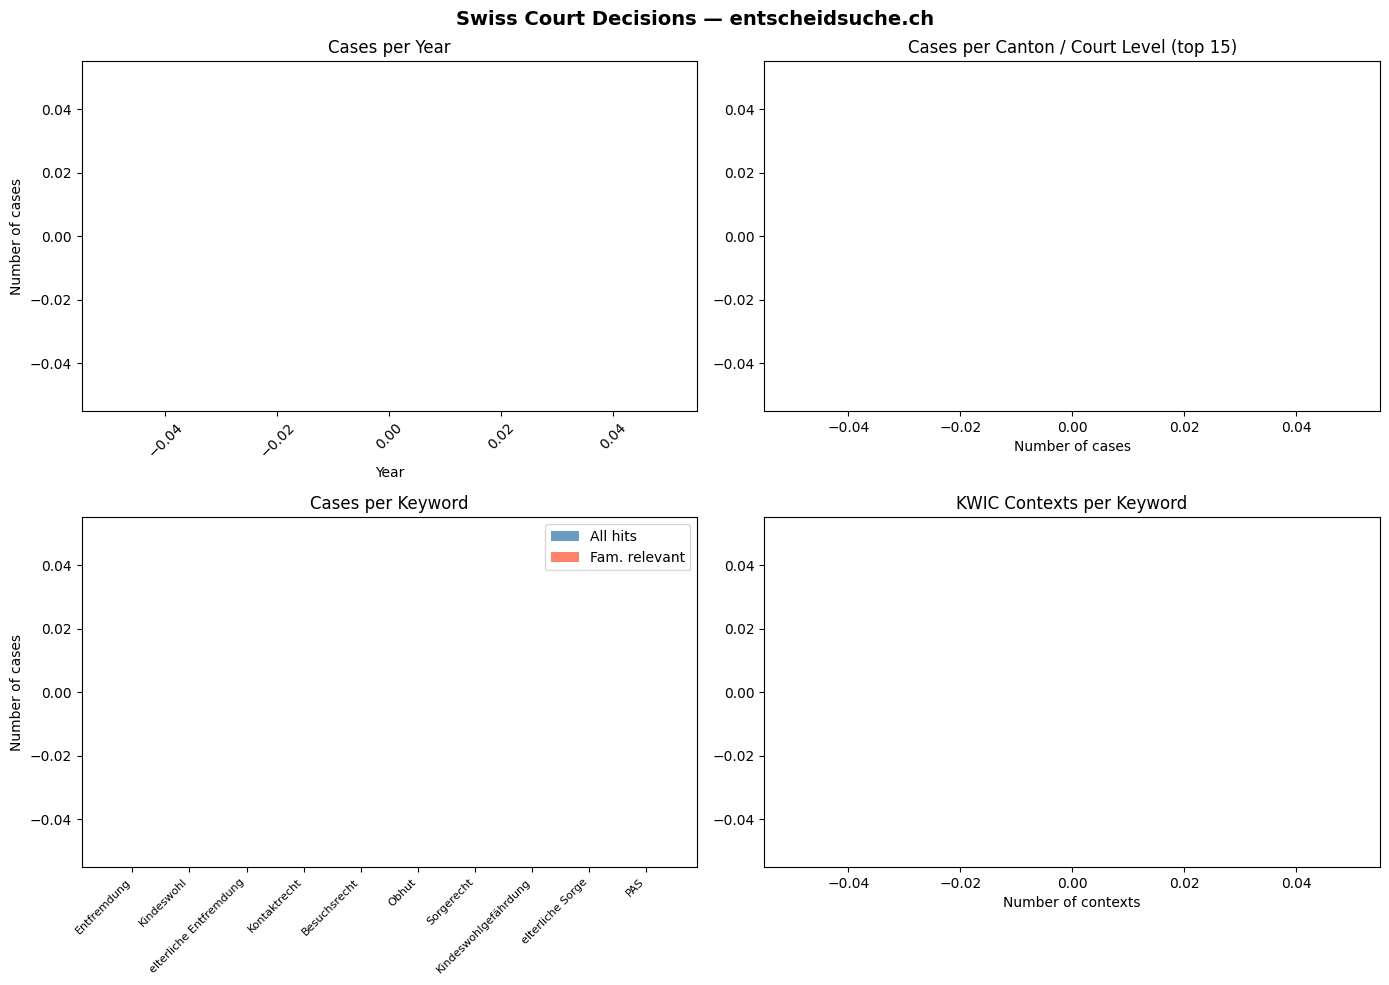

Saved -> ../data/swiss_court_decisions/overview.png


In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Swiss Court Decisions — entscheidsuche.ch", fontsize=14, fontweight="bold")

# Cases per year
ax = axes[0, 0]
years_sorted   = sorted(year_counter.keys())
counts_by_year = [year_counter[y] for y in years_sorted]
ax.bar(years_sorted, counts_by_year, color="steelblue", alpha=0.8)
ax.set_title("Cases per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of cases")
ax.tick_params(axis="x", rotation=45)

# Canton distribution (top 15)
ax = axes[0, 1]
top_cantons = canton_counter.most_common(15)
c_labels = [f"{k} (fed.)" if k == "CH" else k for k, _ in top_cantons]
c_vals   = [v for _, v in top_cantons]
ax.barh(c_labels[::-1], c_vals[::-1], color="teal", alpha=0.8)
ax.set_title("Cases per Canton / Court Level (top 15)")
ax.set_xlabel("Number of cases")

# Keyword counts — all hits vs family-relevant
ax = axes[1, 0]
kw_labels = list(kw_case_counts.keys())
kw_all    = [kw_case_counts[k] for k in kw_labels]
kw_rel    = [kw_relevant_counts[k] for k in kw_labels]
x     = range(len(kw_labels))
width = 0.4
ax.bar([i - width/2 for i in x], kw_all, width, label="All hits",      color="steelblue", alpha=0.8)
ax.bar([i + width/2 for i in x], kw_rel, width, label="Fam. relevant", color="tomato",    alpha=0.8)
ax.set_title("Cases per Keyword")
ax.set_xticks(list(x))
ax.set_xticklabels(kw_labels, rotation=45, ha="right", fontsize=8)
ax.legend()
ax.set_ylabel("Number of cases")

# KWIC contexts per keyword
ax = axes[1, 1]
kwic_kws  = [k for k in KEYWORDS if kwic_per_kw.get(k, 0) > 0]
kwic_vals = [kwic_per_kw[k] for k in kwic_kws]
ax.barh(kwic_kws[::-1], kwic_vals[::-1], color="mediumorchid", alpha=0.8)
ax.set_title("KWIC Contexts per Keyword")
ax.set_xlabel("Number of contexts")

plt.tight_layout()
plt.savefig(OUTPUT_VIZ, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {OUTPUT_VIZ}")

## Notes & Troubleshooting

### Field name mismatches
If the exploration cells show lowercase field names (`sprache`, `datum`, `signatur`),
update `FIELD_LANGUAGE`, `FIELD_DATE`, `FIELD_SIGNATUR` in the config cell accordingly.
If `text` returns no full-text results, try `FIELD_FULLTEXT = "content"` or `"fulltext"`.

### Language filter with `term` returns zero results
If `{"term": {"Sprache": "de"}}` returns nothing, the field is a text type (not keyword).
Switch to `{"match": {"Sprache": "de"}}` in the `filter` clause inside `search_keyword`.

### `_search.php` vs direct ES endpoint
The `_search.php` wrapper may not support all ES features (e.g. `_source.excludes`).
If queries fail at the primary URL, `es_post` automatically falls through to
`https://entscheidsuche.pansoft.de:9200/entscheidsuche-*/_search`.

### HTML 404 (full text missing)
Some decisions are indexed but no longer have an accessible HTML file — these will have
`text_length = 0`. The `abstract` field (from ES metadata) may still contain useful text.

### Pagination limit (10 k)
ES `from+size` caps at 10,000 results per query. If a keyword exceeds this (e.g.
`Kindeswohl` likely will), implement `search_after` pagination using a sort on
`Signatur`, or narrow the date range to run in multiple passes.

### Swiss vs Austrian/German comparison
Austrian RIS (`ris_ogd_api_scraper_v2.ipynb`) uses `Obsorge` where Swiss law uses `Obhut`.
German data (`open_legal_data_germany.ipynb`) uses `Umgangsrecht` where Swiss law uses
`Besuchsrecht`/`Kontaktrecht`. Cross-source comparisons must account for these differences.

### Citation
Data source: **entscheidsuche.ch** — free access to Swiss court decisions.
Please mention entscheidsuche.ch as data source in all publications.
